In [1]:
import pandas as pd
df=pd.read_csv("C:\\Users\\adhil\\OneDrive\\Desktop\\machineworks\\pandasworks\\customer_behaviour\\E-commerce Customer Behavior - Sheet1.csv")
df.head(3)

,Customer ID,Gender,Age,City,Membership Type,Total Spend,Items Purchased,Average Rating,Discount Applied,Days Since Last Purchase,Satisfaction Level
0,101,Female,29,New York,Gold,1120.20,14,4.6,True,25,Satisfied
1,102,Male,34,Los Angeles,Silver,780.50,11,4.1,False,18,Neutral
2,103,Female,43,Chicago,Bronze,510.75,9,3.4,True,42,Unsatisfied


In [2]:
df.columns

Index(['Customer ID', 'Gender', 'Age', 'City', 'Membership Type',
       'Total Spend', 'Items Purchased', 'Average Rating', 'Discount Applied',
       'Days Since Last Purchase', 'Satisfaction Level'],
      dtype='object')

In [3]:
df.isnull().sum()

Customer ID                 0
Gender                      0
Age                         0
City                        0
Membership Type             0
Total Spend                 0
Items Purchased             0
Average Rating              0
Discount Applied            0
Days Since Last Purchase    0
Satisfaction Level          2
dtype: int64

In [4]:
df.rename(columns={"Customer ID": "customer_id","Gender":"gender","Age":"age","Membership Type":"membership_type","Total Spend":"total_spend","Items Purchased":"items_purchased","Average Rating ":"average_rating","Discount Applied":"discount_applied","Days Since Last Purchase":"days_since_last_purchase","Satisfaction Level":"satisfaction_level","City":"city","Average Rating":"average_rating"},inplace=True)

In [5]:
df.isnull().sum()

customer_id                 0
gender                      0
age                         0
city                        0
membership_type             0
total_spend                 0
items_purchased             0
average_rating              0
discount_applied            0
days_since_last_purchase    0
satisfaction_level          2
dtype: int64

In [6]:
df["satisfaction_level"]=df["average_rating"].apply(lambda x :"unsatisfied" if x<=4.0 else "neutral" if x>4.0 and x<4.5 else "satisfied")
# df['satisfaction_level'].fillna(df['satisfaction_level'].mode()[0], inplace=True)


In [7]:
df["gender"].value_counts()

gender
Female    175
Male      175
Name: count, dtype: int64

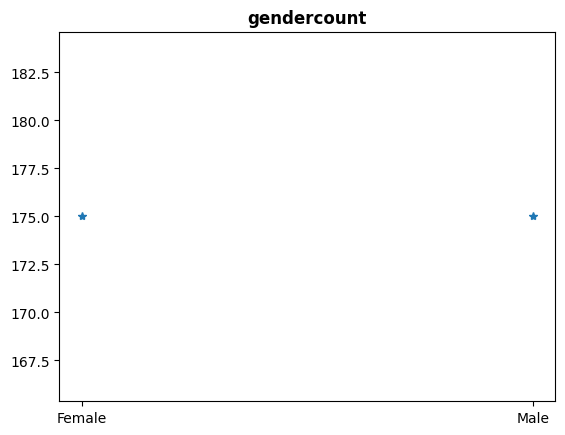

In [8]:
import matplotlib.pyplot as plt
gender=df["gender"].value_counts()
plt.plot(gender,marker="*",linestyle="None")
plt.title("gendercount",weight="bold")
plt.show()

In [9]:
# customer average age
df["age"].mean().astype("int")

np.int64(33)

In [10]:
# unique membership
df["membership_type"].unique()

array(['Gold', 'Silver', 'Bronze'], dtype=object)

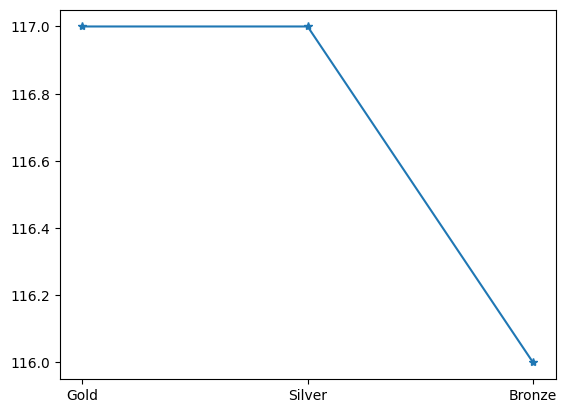

In [11]:
# membership wise count
membership_count=df["membership_type"].value_counts()
plt.plot(membership_count,marker="*")
plt.show()

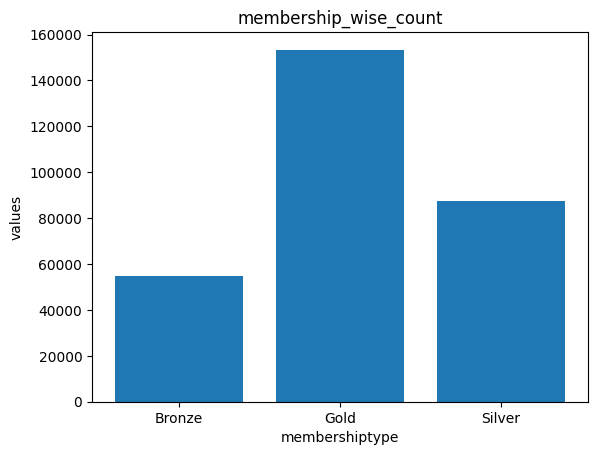

In [12]:
membership_wise_sum=df.groupby("membership_type")["total_spend"].sum()
plt.bar(membership_wise_sum.index,membership_wise_sum.values)
plt.title("membership_wise_count")
plt.xlabel("membershiptype")
plt.ylabel("values")
plt.show()

In [13]:
# gold members
df[df["membership_type"]=="Gold"]


,customer_id,gender,age,city,membership_type,total_spend,items_purchased,average_rating,discount_applied,days_since_last_purchase,satisfaction_level
0,101,Female,29,New York,Gold,1120.2,14,4.6,True,25,satisfied
3,104,Male,30,San Francisco,Gold,1480.3,19,4.7,False,12,satisfied
6,107,Female,31,New York,Gold,1150.6,15,4.5,True,28,satisfied
9,110,Male,28,San Francisco,Gold,1520.1,21,4.8,False,9,satisfied
12,113,Female,30,New York,Gold,1200.8,16,4.3,True,21,neutral
...,...,...,...,...,...,...,...,...,...,...,...
335,436,Female,30,New York,Gold,1200.8,16,4.7,True,28,satisfied
338,439,Male,30,San Francisco,Gold,1460.5,20,4.8,False,15,satisfied
341,442,Female,31,New York,Gold,1140.6,15,4.5,True,36,satisfied
344,445,Male,28,San Francisco,Gold,1480.1,21,4.9,False,13,satisfied


In [14]:
df[df["average_rating"]>4.5]

,customer_id,gender,age,city,membership_type,total_spend,items_purchased,average_rating,discount_applied,days_since_last_purchase,satisfaction_level
0,101,Female,29,New York,Gold,1120.2,14,4.6,True,25,satisfied
3,104,Male,30,San Francisco,Gold,1480.3,19,4.7,False,12,satisfied
9,110,Male,28,San Francisco,Gold,1520.1,21,4.8,False,9,satisfied
15,116,Male,29,San Francisco,Gold,1360.2,18,4.9,False,11,satisfied
18,119,Female,32,New York,Gold,1170.3,14,4.7,True,29,satisfied
...,...,...,...,...,...,...,...,...,...,...,...
326,427,Male,30,San Francisco,Gold,1450.5,19,4.6,False,14,satisfied
332,433,Male,28,San Francisco,Gold,1490.1,21,4.9,False,11,satisfied
335,436,Female,30,New York,Gold,1200.8,16,4.7,True,28,satisfied
338,439,Male,30,San Francisco,Gold,1460.5,20,4.8,False,15,satisfied


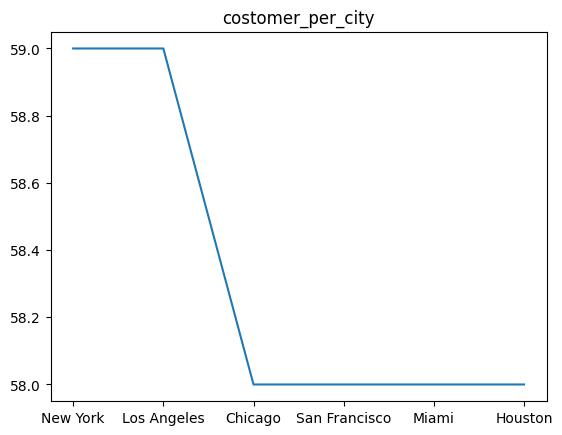

In [15]:
customer_per_city=df["city"].value_counts()
plt.title("costomer_per_city")
plt.plot(customer_per_city)
plt.show()

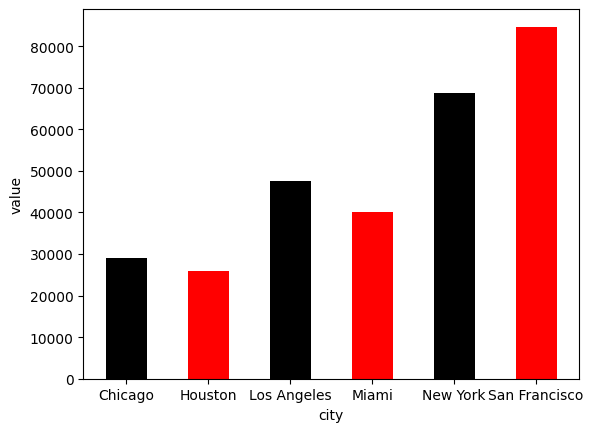

In [16]:
# city wise total spend [plot]
city_wise_count=df.groupby("city")["total_spend"].sum()
plt.bar(city_wise_count.index,city_wise_count.values,width=0.5,color=("black","red"))
plt.xlabel("city")
plt.ylabel("value")
plt.show()

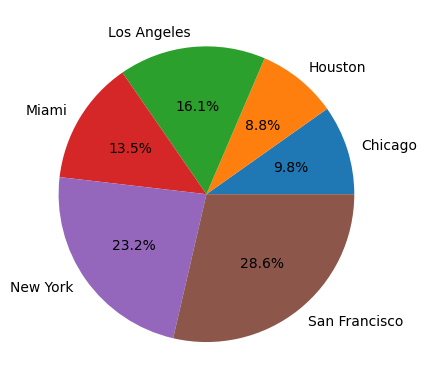

In [17]:
# city wise total spend [plot]
city_wise_count=df.groupby("city")["total_spend"].sum()
plt.pie(city_wise_count.values,labels=city_wise_count.index,autopct="%1.1f%%")
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

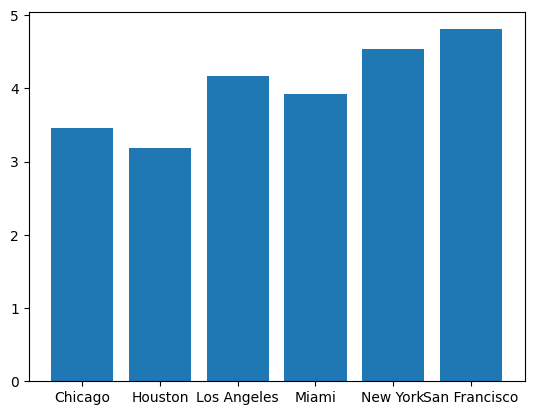

In [18]:
city_wise_rating=df.groupby("city")["average_rating"].mean()
plt.bar(city_wise_rating.index,city_wise_rating.values)
plt.show

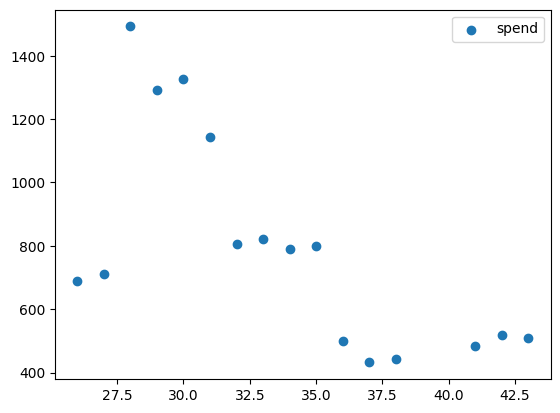

In [19]:
# age wise total count
age_total_spend=df.groupby("age")["total_spend"].mean()
plt.scatter(age_total_spend.index,age_total_spend.values,label="spend")
plt.legend()

(array([ 69., 106.,  84.,  33.,  58.]),
 array([26. , 29.4, 32.8, 36.2, 39.6, 43. ]),
 <BarContainer object of 5 artists>)

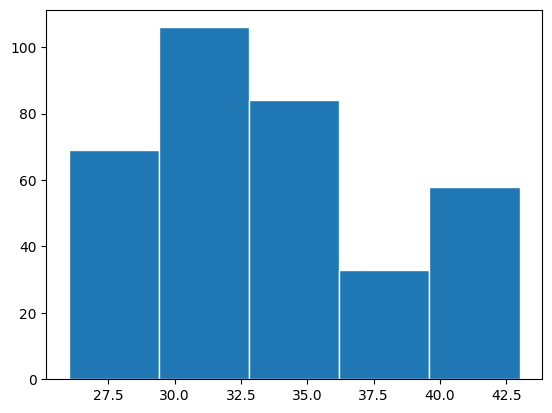

In [20]:
plt.hist(df["age"],bins=5,edgecolor="white")

<BarContainer object of 5 artists>

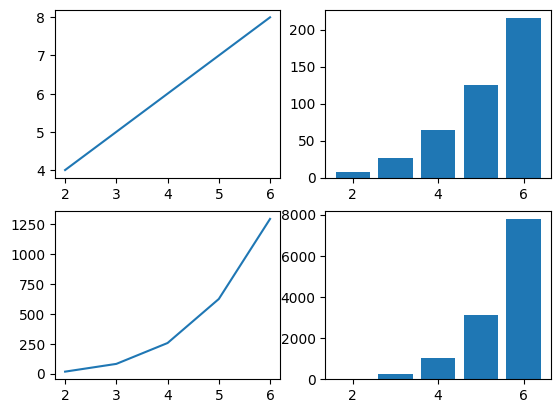

In [33]:
import numpy as np
figure,axes=plt.subplots(2,2)
x=np.array([2,3,4,5,6])
axes[0,0].plot(x,x+2)
axes[0,1].bar(x,x**3)
axes[1,0].plot(x,x**4)
axes[1,1].bar(x,x**5)


{'whiskers': [<matplotlib.lines.Line2D at 0x2b7bdf23620>,
 'caps': [<matplotlib.lines.Line2D at 0x2b7bdf23ad0>,
 'boxes': [<matplotlib.lines.Line2D at 0x2b7bdf23440>],
 'medians': [<matplotlib.lines.Line2D at 0x2b7bdf48110>],
 'fliers': [<matplotlib.lines.Line2D at 0x2b7bdf483b0>],
 'means': []}

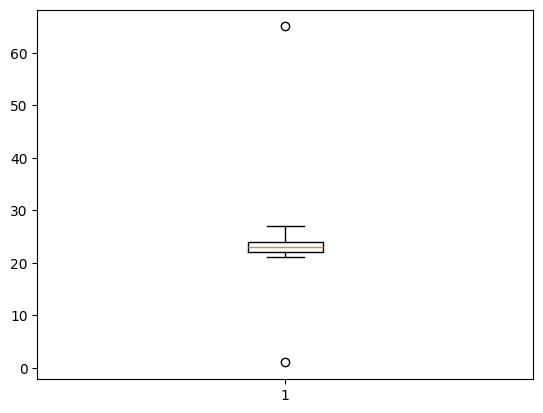

In [37]:
age=[23,21,23,24,25,26,27,21,23,22,22,22,22,23,24,65,1,21,22,23]
plt.boxplot(age)